In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("titanic.csv")

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.shape

(891, 12)

In [13]:
df.size

10692

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
from sklearn.impute import SimpleImputer

In [16]:
si=SimpleImputer(strategy="mean")
df[["Age"]]=si.fit_transform(df[["Age"]])

In [17]:
si=SimpleImputer(strategy="most_frequent")
df[["Cabin"]]=si.fit_transform(df[["Cabin"]])
df[["Embarked"]]=si.fit_transform(df[["Embarked"]])

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [19]:
from sklearn.preprocessing import LabelEncoder
cols2=["Name","Sex","Age","Ticket","Cabin","Embarked"]
le=LabelEncoder()
for col in cols2:
    df[col]=le.fit_transform(df[col])

In [20]:
from sklearn.preprocessing import StandardScaler
cols2=["SibSp","Parch","PassengerId","Pclass","Fare"]
sc=StandardScaler()
df[cols2]=sc.fit_transform(df[cols2])

In [21]:
import math
cols=df.columns.tolist()
n=len(cols)
rows=math.ceil(n/2)

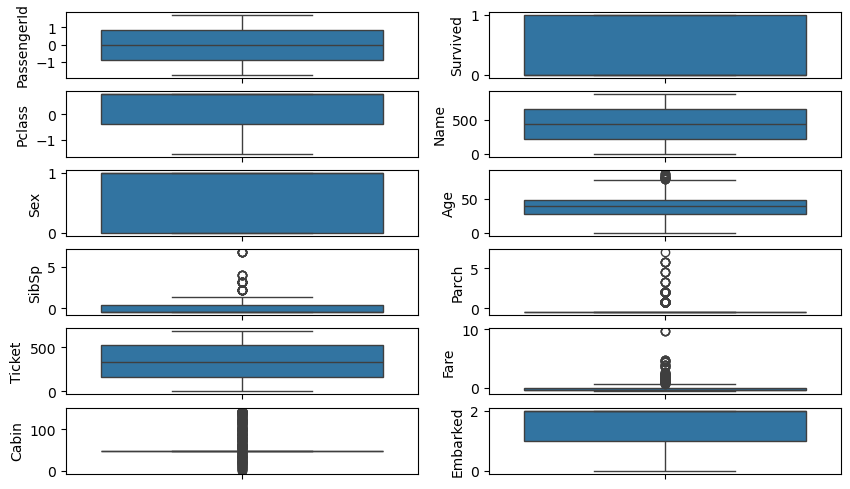

In [22]:
plt.figure(figsize=(10,6))
for i in range(len(cols)):
    plt.subplot(rows,2,i+1)
    sns.boxplot(df[cols[i]])
    plt.xticks(rotation=45,ha="right")

In [23]:
from scipy.stats.mstats import winsorize

In [24]:
cols1=["Age","SibSp","Cabin","Parch","Fare"]

In [25]:
for i in cols1:
    df[i]=winsorize(df[i],limits=(0.3,0.3))

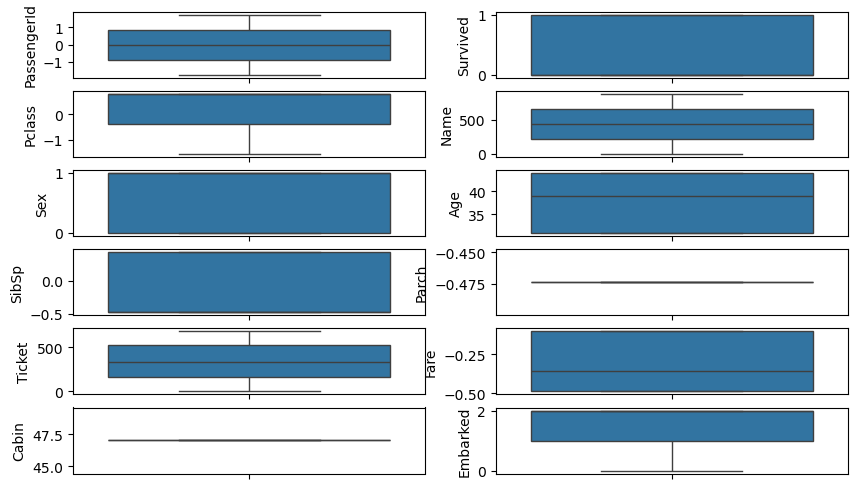

In [26]:
plt.figure(figsize=(10,6))
for i in range(len(cols)):
    plt.subplot(rows,2,i+1)
    sns.boxplot(df[cols[i]])
    plt.xticks(rotation=45,ha="right")

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.ensemble import RandomForestClassifier

In [28]:
X=df.drop(["Survived","Ticket","Fare"],axis=1)
y=df["Survived"]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
rfc=RandomForestClassifier(max_depth=10,n_estimators=200,criterion="entropy",min_samples_split=5,min_samples_leaf=2,max_features="sqrt",random_state=42)

In [31]:
rfc.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [32]:
y_pred=rfc.predict(X_test)

In [33]:
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.8156424581005587


In [34]:
cm=confusion_matrix(y_test,y_pred)

In [35]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
plt.show()

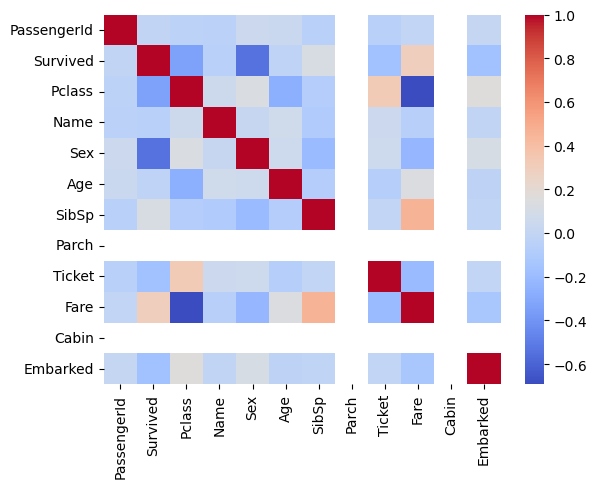

In [37]:
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [39]:
plt.figure(figsize=(20,10))
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=["Survived","Not Survived"],
    filled=True,
    max_depth=10)
plt.show()

NameError: name 'plot_tree' is not defined

<Figure size 2000x1000 with 0 Axes>